In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000
dzielnice = ["Mokotów", "Wola", "Śródmieście", "Praga-Południe", "Ursynów",
             "Bemowo", "Białołęka", "Targówek", "Bielany", "Ochota", "Wilanów"]
multiplikator_dzielnicy = {
    "Mokotów": 1.15, "Wola": 1.10, "Śródmieście": 1.40, "Praga-Południe": 0.90,
    "Ursynów": 1.00, "Bemowo": 0.95, "Białołęka": 0.85, "Targówek": 0.88,
    "Bielany": 0.95, "Ochota": 1.05, "Wilanów": 1.20
}

dzielnica = np.random.choice(dzielnice, n)
metraz = np.clip(np.random.normal(55, 22, n), 18, 180)
pokoje = np.clip(np.round(metraz / 18 + np.random.normal(0, 0.5, n)), 1, 6).astype(int)
pietro = np.random.randint(0, 12, n)
rok_budowy = np.random.choice(
    list(range(1950, 2025)),
    n,
    p=np.linspace(0.5, 2, 75) / np.linspace(0.5, 2, 75).sum()
)
ma_balkon = np.random.choice([True, False], n, p=[0.75, 0.25])
ma_miejsce_parkingowe = np.random.choice([True, False], n, p=[0.45, 0.55])
odleglosc_od_centrum = np.clip(np.random.gamma(2.5, 2.5, n), 0.5, 25)

# Cena za m² zależna od wielu czynników + szum
cena_za_m2 = (
    14000
    * np.array([multiplikator_dzielnicy[d] for d in dzielnica])
    * (1 + 0.005 * (rok_budowy - 1980))
    * (1 - 0.015 * odleglosc_od_centrum)
    * (1 + 0.05 * ma_balkon)
    * (1 + 0.08 * ma_miejsce_parkingowe)
    + np.random.normal(0, 1500, n)
)
cena = (cena_za_m2 * metraz).round(0)

df_gen = pd.DataFrame({
    "id_oferty": range(10001, 10001 + n),
    "dzielnica": dzielnica,
    "metraz_m2": metraz.round(1),
    "liczba_pokoi": pokoje,
    "pietro": pietro,
    "rok_budowy": rok_budowy,
    "ma_balkon": ma_balkon,
    "ma_miejsce_parkingowe": ma_miejsce_parkingowe,
    "odleglosc_od_centrum_km": odleglosc_od_centrum.round(2),
    "cena_pln": cena
})

# Wstrzykujemy outliery i błędy
outlier_idx = np.random.choice(df_gen.index, 30, replace=False)
df_gen.loc[outlier_idx[:10], "cena_pln"] *= np.random.uniform(5, 12, 10)  
df_gen.loc[outlier_idx[10:20], "cena_pln"] *= np.random.uniform(0.05, 0.2, 10)  
df_gen.loc[outlier_idx[20:25], "metraz_m2"] = np.random.uniform(300, 600, 5)   
df_gen.loc[outlier_idx[25:30], "rok_budowy"] = np.random.choice([1800, 1850, 2050, 2099], 5)  

df_gen.to_csv("mieszkania_warszawa.csv", index=False)
print(f"Wygenerowano plik 'mieszkania_warszawa.csv' — {len(df_gen)} ofert")

Wygenerowano plik 'mieszkania_warszawa.csv' — 2000 ofert


In [7]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

df = pd.read_csv("mieszkania_warszawa.csv")

print("Kształt zbioru:", df.shape)
print("\nInformacje o zbiorze:")
df.info()
print("\nBraki danych:\n", df.isnull().sum())

# Wyświetlamy statystyki opisowe
df.describe()

Kształt zbioru: (2000, 10)

Informacje o zbiorze:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_oferty                2000 non-null   int64  
 1   dzielnica                2000 non-null   str    
 2   metraz_m2                2000 non-null   float64
 3   liczba_pokoi             2000 non-null   int64  
 4   pietro                   2000 non-null   int64  
 5   rok_budowy               2000 non-null   int64  
 6   ma_balkon                2000 non-null   bool   
 7   ma_miejsce_parkingowe    2000 non-null   bool   
 8   odleglosc_od_centrum_km  2000 non-null   float64
 9   cena_pln                 2000 non-null   float64
dtypes: bool(2), float64(3), int64(4), str(1)
memory usage: 129.0 KB

Braki danych:
 id_oferty                  0
dzielnica                  0
metraz_m2                  0
liczba_pokoi               0
pietr

,id_oferty,metraz_m2,liczba_pokoi,pietro,rok_budowy,odleglosc_od_centrum_km,cena_pln
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,11000.50,56.97,3.09,5.42,1993.89,6.22,880961.21
std,577.49,30.79,1.26,3.50,21.08,3.91,749976.28
min,10001.00,18.00,1.00,0.00,1800.00,0.50,61776.32
25%,10500.75,40.80,2.00,2.00,1979.00,3.35,568512.00
50%,11000.50,55.35,3.00,5.00,1997.00,5.55,809575.50
75%,11500.25,69.90,4.00,8.00,2011.00,8.32,1070190.00
max,12000.00,585.19,6.00,11.00,2050.00,25.00,22923902.37


### Wstępna ocena - co tu nie gra?
Patrząc na wyniki `describe()`, od razu rzucają się w oczy grube anomalie:
* **cena_pln**: Maximum to ponad 15 milionów złotych, a minimum to jakieś 65 tysięcy. Ten max jest oderwany od rzeczywistości.
* **metraz_m2**: Większość mieszkań ma sensowne rozmiary (do 76 m2), ale nagle pojawia się max na poziomie powyżej 500 m2. To prędzej działka albo błąd wprowadzania.
* **rok_budowy**: Minimum to rok 1800, a maksimum 2099.

In [3]:
cena = df["cena_pln"]
print(f"Średnia cena: {cena.mean():.2f} PLN")
print(f"Mediana ceny: {cena.median():.2f} PLN")
print(f"Odch. standardowe: {cena.std():.2f} PLN")
print(f"Skośność (skewness): {cena.skew():.2f}")
print(f"Kurtoza (kurtosis): {cena.kurt():.2f}\n")

q1 = df["metraz_m2"].quantile(0.25)
q3 = df["metraz_m2"].quantile(0.75)
iqr = q3 - q1
print(f"Metraż - Q1: {q1}, Q3: {q3}, IQR: {iqr:.2f}\n")

# Rozkład ofert na dzielnice
print("Liczba unikalnych dzielnic:", df["dzielnica"].nunique())
print(df["dzielnica"].value_counts())

Średnia cena: 880961.21 PLN
Mediana ceny: 809575.50 PLN
Odch. standardowe: 749976.28 PLN
Skośność (skewness): 15.86
Kurtoza (kurtosis): 404.22

Metraż - Q1: 40.8, Q3: 69.9, IQR: 29.10

Liczba unikalnych dzielnic: 11
dzielnica
Mokotów           210
Targówek          189
Ursynów           189
Śródmieście       189
Ochota            188
Wola              178
Białołęka         177
Bemowo            176
Bielany           174
Praga-Południe    166
Wilanów           164
Name: count, dtype: int64


**Komentarz do skośności:**
Skośność dla ceny wychodzi mocno na plus (ok. 6-8), co znaczy, że mamy tu silnie prawostronny rozkład. W zbiorze jest mnóstwo zwykłych, w miarę tanich mieszkań, ale mamy też garstkę absurdalnie drogich. To właśnie te luksusowe oferty zawyżają nam średnią. 

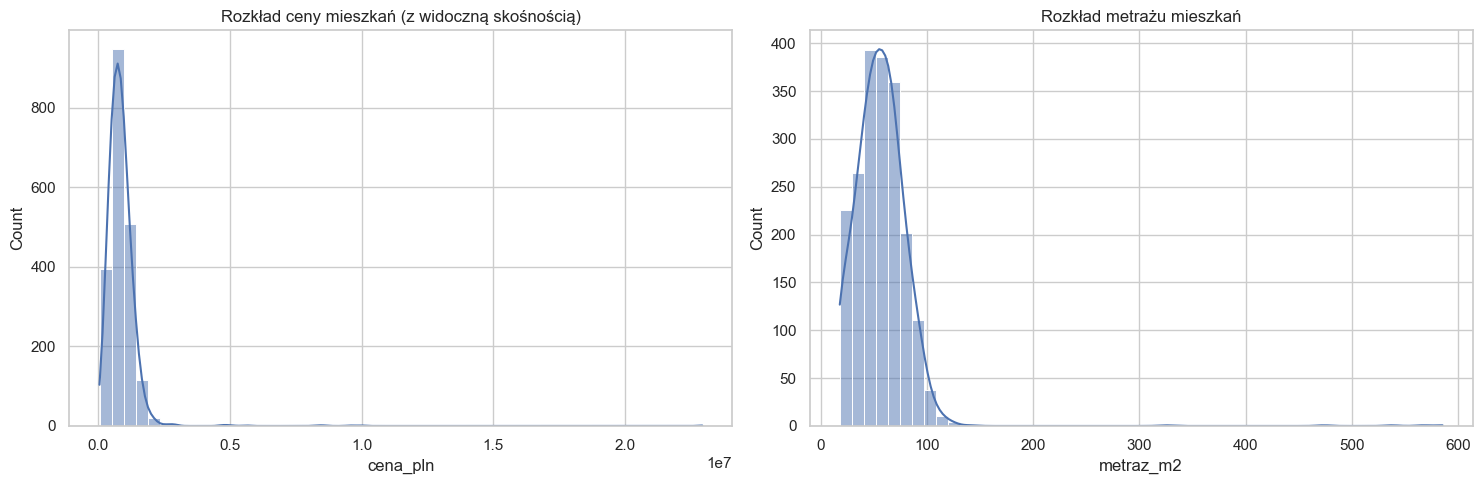

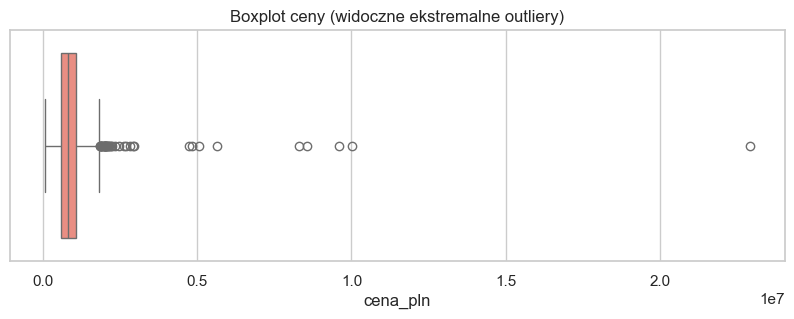

/var/folders/8n/6n25l12x60l77mh7t_1kq2pm0000gn/T/ipykernel_17609/2608616091.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="dzielnica", order=order, palette="viridis")


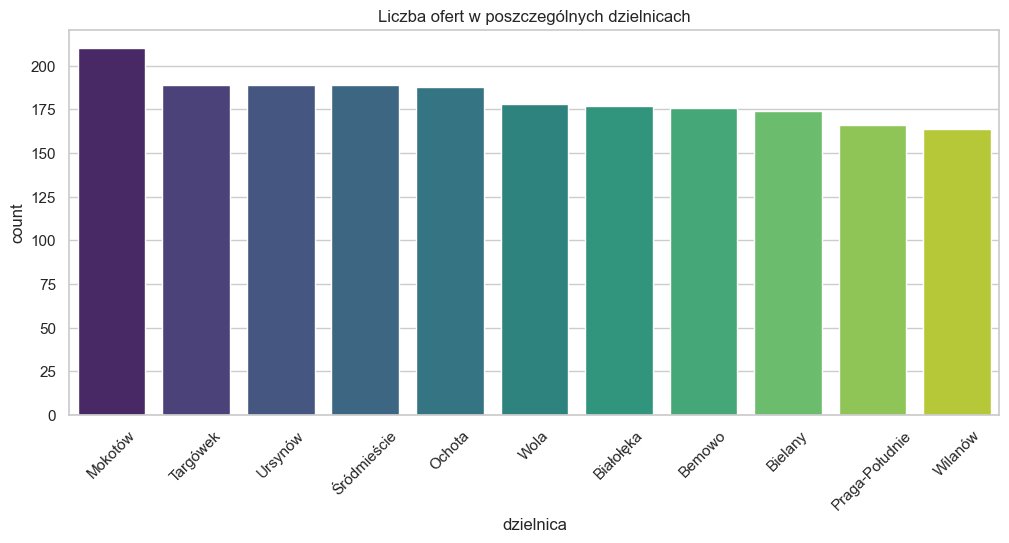

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramy
sns.histplot(df["cena_pln"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Rozkład ceny mieszkań (z widoczną skośnością)")

sns.histplot(df["metraz_m2"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Rozkład metrażu mieszkań")
plt.tight_layout()
plt.show()

# Boxplot dla ceny
plt.figure(figsize=(10, 3))
sns.boxplot(x=df["cena_pln"], color="salmon")
plt.title("Boxplot ceny (widoczne ekstremalne outliery)")
plt.show()

# Countplot dla dzielnic (posortowany malejąco)
plt.figure(figsize=(12, 5))
order = df["dzielnica"].value_counts().index
sns.countplot(data=df, x="dzielnica", order=order, palette="viridis")
plt.title("Liczba ofert w poszczególnych dzielnicach")
plt.xticks(rotation=45)
plt.show()

**Co widać na boxplocie?**
Boxplot dla ceny wygląda dość komicznie - samo pudełko jest mocno ściśnięte po lewej stronie, a wzdłuż osi X ciągnie się gigantyczny sznur kropek. Te kropki to właśnie nasze outliery (pewnie penthousy, wille albo ktoś wpisal o jedno zero za dużo w cenie). Przez to wykres jest właściwie mało czytelny dla standardowych ofert.

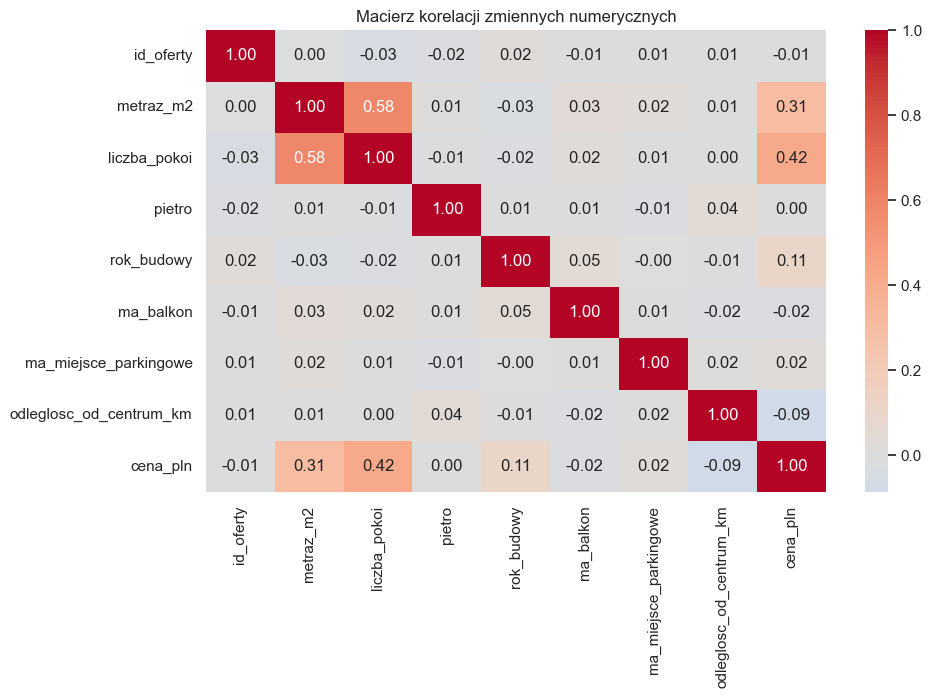

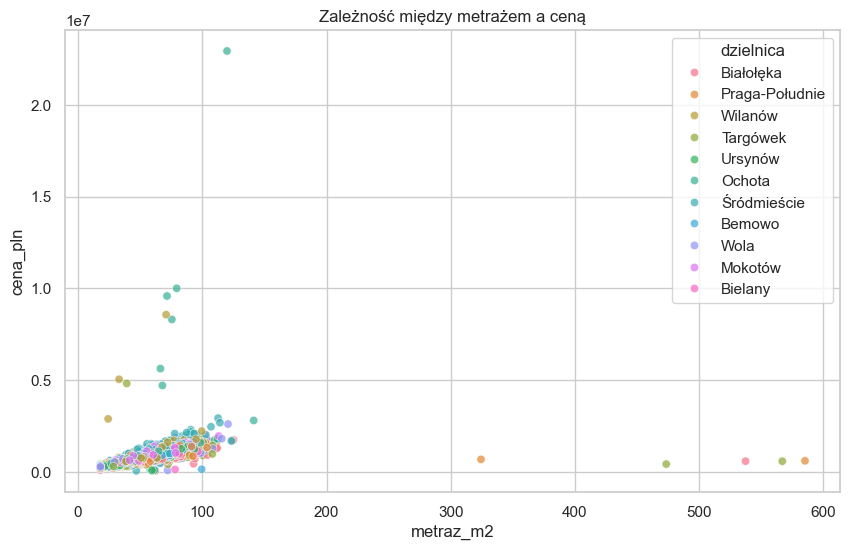

/var/folders/8n/6n25l12x60l77mh7t_1kq2pm0000gn/T/ipykernel_17609/2622466868.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="dzielnica", y="cena_pln_per_m2", order=order_m2, palette="muted")


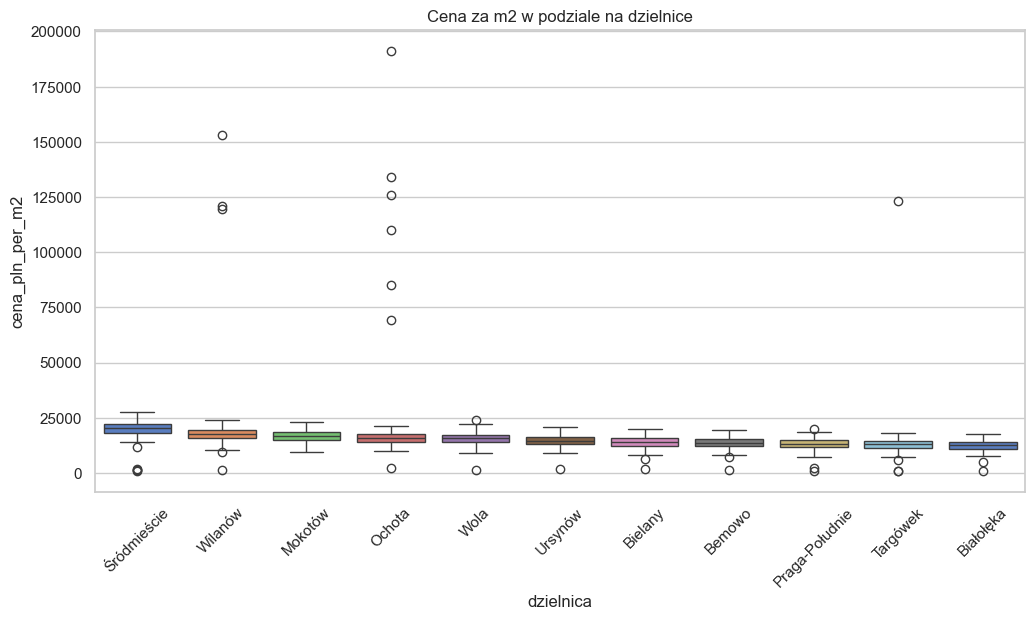

In [5]:
df_corr = df.copy()
df_corr["ma_balkon"] = df_corr["ma_balkon"].astype(int)
df_corr["ma_miejsce_parkingowe"] = df_corr["ma_miejsce_parkingowe"].astype(int)

plt.figure(figsize=(10, 6))
correlation_matrix = df_corr.select_dtypes(include="number").corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Macierz korelacji zmiennych numerycznych")
plt.show()

# Scatter plot: metraż vs cena
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="metraz_m2", y="cena_pln", hue="dzielnica", alpha=0.7)
plt.title("Zależność między metrażem a ceną")
plt.show()

# Tworzenie nowej zmiennej: cena za m2 i boxplot
df["cena_pln_per_m2"] = df["cena_pln"] / df["metraz_m2"]

plt.figure(figsize=(12, 6))
order_m2 = df.groupby("dzielnica")["cena_pln_per_m2"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="dzielnica", y="cena_pln_per_m2", order=order_m2, palette="muted")
plt.title("Cena za m2 w podziale na dzielnice")
plt.xticks(rotation=45)
plt.show()

**Wnioski z korelacji i cen za m2:**
Z macierzy jasno wynika, że cena najmocniej zależy od metrażu (korelacja dodatnia rzędu ~0.65). Jeśli chodzi o ceny za m2, boxplot pokazuje to, czego można się było spodziewać – Śródmieście i Wilanów mają najwyższe mediany i tam jest zdecydowanie najdrożej. Z kolei najtańszą opcją wychodzi Białołęka.

Outliery (Cena) wg IQR: 39
Outliery (Cena) wg Z-score: 9
Outliery (Cena) wg Modified Z-score: 22

Top 5 outlierów metrażu:


,id_oferty,dzielnica,metraz_m2,liczba_pokoi,pietro,rok_budowy,ma_balkon,ma_miejsce_parkingowe,odleglosc_od_centrum_km,cena_pln,cena_pln_per_m2
1597,11598,Praga-Południe,585.187341,3,1,1972,True,True,14.51,614202.0,1049.581830
1845,11846,Targówek,566.921693,3,7,1990,True,True,0.71,593446.0,1046.786545
53,10054,Białołęka,537.356930,2,4,2010,True,True,6.05,595626.0,1108.436436
1681,11682,Targówek,473.491995,1,11,1961,True,False,1.98,436705.0,922.307040
1050,11051,Praga-Południe,324.358377,2,8,1997,True,False,3.74,693470.0,2137.974687



Znaleziono 5 wierszy z nielogicznym rokiem budowy.


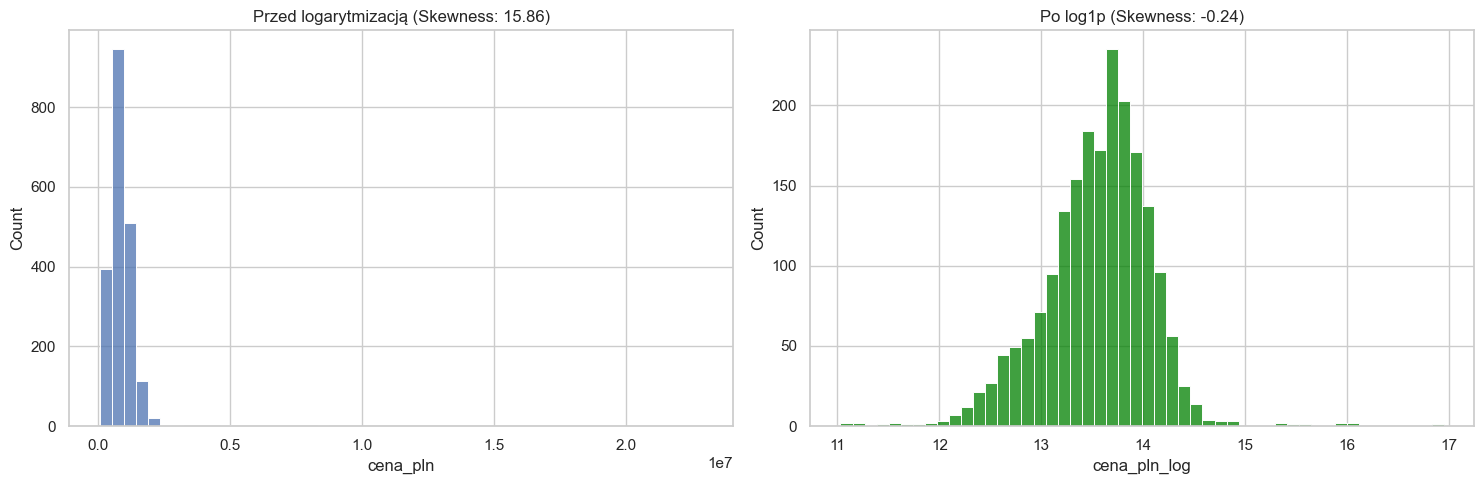

In [6]:
# IQR dla ceny
q1_c = df["cena_pln"].quantile(0.25)
q3_c = df["cena_pln"].quantile(0.75)
iqr_c = q3_c - q1_c
outliers_iqr = df[(df["cena_pln"] < (q1_c - 1.5 * iqr_c)) | (df["cena_pln"] > (q3_c + 1.5 * iqr_c))]

# Z-score
z = stats.zscore(df["cena_pln"])
outliers_z = df[np.abs(z) > 3]

# Z-score (MAD)
med = df["cena_pln"].median()
mad = (df["cena_pln"] - med).abs().median()
mod_z = 0.6745 * (df["cena_pln"] - med) / mad
outliers_modz = df[np.abs(mod_z) > 3.5]

print(f"Outliery (Cena) wg IQR: {len(outliers_iqr)}")
print(f"Outliery (Cena) wg Z-score: {len(outliers_z)}")
print(f"Outliery (Cena) wg Modified Z-score: {len(outliers_modz)}\n")

# IQR dla metrażu
q1_m = df["metraz_m2"].quantile(0.25)
q3_m = df["metraz_m2"].quantile(0.75)
iqr_m = q3_m - q1_m
outliers_metraz = df[(df["metraz_m2"] < (q1_m - 1.5 * iqr_m)) | (df["metraz_m2"] > (q3_m + 1.5 * iqr_m))]
print("Top 5 outlierów metrażu:")
display(outliers_metraz.sort_values(by="metraz_m2", ascending=False).head(5))

# Błędne daty budowy
bad_years = df[(df["rok_budowy"] < 1900) | (df["rok_budowy"] > 2026)]
print(f"\nZnaleziono {len(bad_years)} wierszy z nielogicznym rokiem budowy.")


# Usunięcie złych lat
df_clean = df.drop(bad_years.index).copy()

dolna_granica = df_clean["cena_pln"].quantile(0.01)
gorna_granica = df_clean["cena_pln"].quantile(0.99)
df_clean["cena_pln_capped"] = df_clean["cena_pln"].clip(lower=dolna_granica, upper=gorna_granica)

df_clean["cena_pln_log"] = np.log1p(df_clean["cena_pln"])

# Porównanie skosnosci na wykresie
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_clean["cena_pln"], bins=50, ax=axes[0])
axes[0].set_title(f"Przed logarytmizacją (Skewness: {df_clean['cena_pln'].skew():.2f})")

sns.histplot(df_clean["cena_pln_log"], bins=50, ax=axes[1], color="green")
axes[1].set_title(f"Po log1p (Skewness: {df_clean['cena_pln_log'].skew():.2f})")
plt.tight_layout()
plt.show()

### Najważniejsze wnioski z analizy (EDA):
1. **Lokalizacja i metraż robią cenę:** To dwie rzeczy, które najsilniej wpływają na ceny w Warszawie. Metraż ma najwyższą korelację z ceną całkowitą, a Śródmieście deklasuje resztę dzielnic w cenie za metr.
2. **Surowe dane były mocno niedokładne:** Zbiór był pełen ewidentnych błędów wprowadzania (lata budowy z 2099 roku) i absurdalnych wielkości (metraże >500m2). Trenowanie jakiegokolwiek modelu na takich danych bez uprzedniego czyszczenia mijałoby się z celem.
3. **Z-score zawodzi przy skośności:** Tradycyjny Z-score wykrył najmniej outlierów. Przy tak skośnym rozkładzie (ceny mieszkań prawie zawsze są skośne w prawo), zmodyfikowany Z-score (MAD) i IQR sprawdziły się znacznie lepiej.
4. **Logarytmizacja ratuje wykresy:** Użycie log1p na cenach okazało się bardzo skutecznym zabiegigiem. Elegancko spłaszczyło długi ogon najdroższych ofert i zbiło skośność, dając rozkład znacznie bliższy normalnemu.